Ex 1

In [89]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [90]:
#Ex 1.1
data = pd.read_csv("passengercarmileage.txt", sep="\t", index_col=0)

#data.head()
#print(data.columns)
# print(data.shape)
# print(data.dtypes)
# data.isna().sum()

model = smf.ols('MPG ~ HP', data=data).fit()
print(f"n = {len(data)}")
print(f"Fitted equation: MPG = {model.params['Intercept']:.1f} "f"+ {model.params['HP']:.3f} × HP")
print(model.params)

n = 82
Fitted equation: MPG = 50.1 + -0.139 × HP
Intercept    50.066078
HP           -0.139023
dtype: float64


                            OLS Regression Results                            
Dep. Variable:                    MPG   R-squared:                       0.624
Model:                            OLS   Adj. R-squared:                  0.619
Method:                 Least Squares   F-statistic:                     132.7
Date:                Wed, 07 Oct 2026   Prob (F-statistic):           1.15e-18
Time:                        18:28:00   Log-Likelihood:                -264.61
No. Observations:                  82   AIC:                             533.2
Df Residuals:                      80   BIC:                             538.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     50.0661      1.569     31.900      0.0

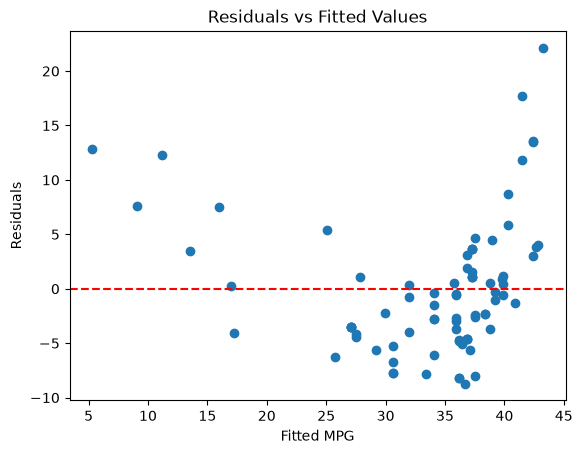

In [91]:
x = model.fittedvalues
y = model.resid

print(model.summary())


plt.scatter(x, y)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Fitted MPG")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()


The residuals do not appear randomly scattered around 0. This suggests it doesnt support the use of linear regression

n = 82
Fitted equation: log(MPG) = 4.0 + -0.005 × HP
Intercept    4.013229
HP          -0.004589
dtype: float64


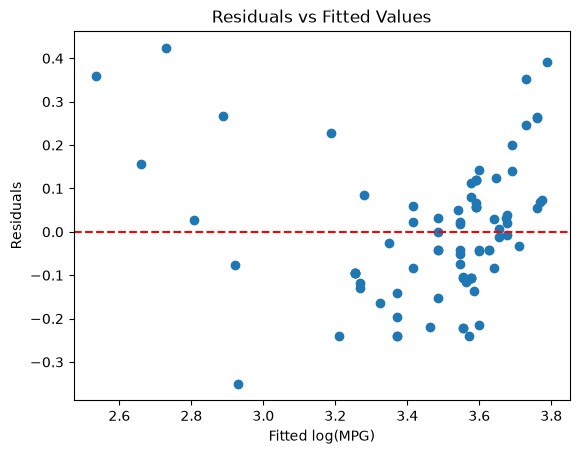

                            OLS Regression Results                            
Dep. Variable:                log_MPG   R-squared:                       0.734
Model:                            OLS   Adj. R-squared:                  0.731
Method:                 Least Squares   F-statistic:                     221.2
Date:                Wed, 07 Oct 2026   Prob (F-statistic):           9.62e-25
Time:                        18:28:00   Log-Likelihood:                 36.047
No. Observations:                  82   AIC:                            -68.09
Df Residuals:                      80   BIC:                            -63.28
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.0132      0.040    100.021      0.0

In [92]:
# Ex 1.2
data = pd.read_csv("passengercarmileage.txt", sep="\t", index_col=0)
data["log_MPG"] = np.log(data["MPG"])

model = smf.ols('log_MPG ~ HP', data=data).fit()
print(f"n = {len(data)}")
print(f"Fitted equation: log(MPG) = {model.params['Intercept']:.1f} "f"+ {model.params['HP']:.3f} × HP")
print(model.params)

x = model.fittedvalues
y = model.resid

plt.scatter(x, y)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Fitted log(MPG)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()
print(model.summary())


With log(MPG) the residuals still do not appear randomly scattered around 0. This suggests neither log or regular MPG do not support the use of linear regression

n = 82
Fitted equation: MPG = 192.4 + 0.392 × HP
Intercept    192.437753
HP             0.392212
VOL           -0.015645
SP            -1.294818
WT            -1.859804
dtype: float64


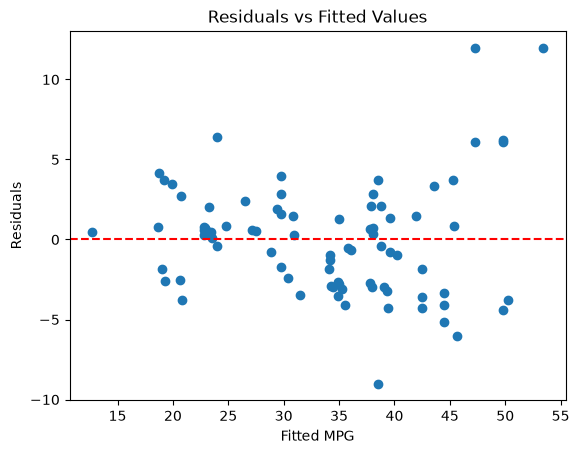

                            OLS Regression Results                            
Dep. Variable:                    MPG   R-squared:                       0.873
Model:                            OLS   Adj. R-squared:                  0.867
Method:                 Least Squares   F-statistic:                     132.7
Date:                Wed, 07 Oct 2026   Prob (F-statistic):           9.98e-34
Time:                        18:28:00   Log-Likelihood:                -220.00
No. Observations:                  82   AIC:                             450.0
Df Residuals:                      77   BIC:                             462.0
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    192.4378     23.532      8.178      0.0

In [93]:
# Ex 1.3
data = pd.read_csv("passengercarmileage.txt", sep="\t", index_col=0)

#VOL	HP	MPG	SP	WT

model = smf.ols('MPG ~ HP + VOL + SP + WT', data=data).fit()
print(f"n = {len(data)}")
print(f"Fitted equation: MPG = {model.params['Intercept']:.1f} "f"+ {model.params['HP']:.3f} × HP")
print(model.params)

x = model.fittedvalues
y = model.resid

plt.scatter(x, y)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Fitted MPG")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()
print(model.summary())

def standardize(x):
    return (x - x.mean()) / (2 * x.std())

data['sHP'] = standardize(data['HP'])
data['sVOL'] = standardize(data['VOL'])
data['sSP'] = standardize(data['SP'])
data['sWT'] = standardize(data['WT'])
model_std = smf.ols('MPG ~ sHP + sVOL + sSP + sWT', data=data).fit()
print(f"Standardized HP coef: {model_std.params['sHP']:.2f}")
print(f"Standardized VOL coef: {model_std.params['sVOL']:.2f}")
print(f"Standardized SP coef: {model_std.params['sSP']:.2f}")
print(f"Standardized WT coef: {model_std.params['sWT']:.2f}")

With the multiple linear regression the residuals appear approximately randomly scattered around 0. This provides better support for the linearity assumption than the simple regression models.

In [94]:
# Ex 3.1
import pymc as pm
import numpy as np
import arviz as az

# --- Data and Hyperparameters ---
X_data = np.array([-0.02, -0.03, 0.82, -1.05, -0.76, 0.46, -0.06, 0.34, -0.08, -0.24, 1.43, 1.07, -2.5, 1.48, 2.16, 1.23, -0.21, -0.69, 0.73, -0.62]) # The observed data
#print(f"Observed data: {len(X_data)}")
sigma_known = 1.0        # Standard deviation for data (known)
theta_mean = 0.0         # Prior mean for theta
theta_std = 0.4          # Prior standard deviation for theta

# --- Model Definition ---
with pm.Model() as model_part_a:
    # Prior for theta
    theta = pm.Normal('theta', mu=theta_mean, sigma=theta_std)

    # Likelihood of the data
    X_obs = pm.Normal('X_obs', mu=theta, sigma=sigma_known, observed=X_data)

with model_part_a:
    # Sample using NUTS (No-U-Turn Sampler)
    idata = pm.sample(draws=500, tune=500,
    random_seed=42,
    progressbar=False)

print(
    az.summary(
        idata,
        var_names=["theta"],
        kind="diagnostics"
    )
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta]
Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 0 seconds.


      ess_bulk ess_tail r_hat mcse_mean mcse_sd
theta      925     1255  1.00    0.0063  0.0036


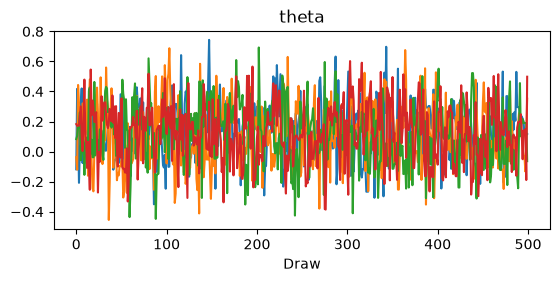

In [95]:
az.plot_trace(idata, var_names=["theta"])

In [96]:
print(
    az.summary(
        idata,
        var_names=["theta"]
    )
)

       mean     sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean mcse_sd
theta  0.12  0.192    -0.18     0.43      925     1255  1.00    0.0063  0.0036


In [97]:
# Ex 3.2
import pymc as pm
import numpy as np
import arviz as az

# --- Data and Hyperparameters ---
X_data = np.array([-0.02, -0.03, 0.82, -1.05, -0.76, 0.46, -0.06, 0.34, -0.08, -0.24, 1.43, 1.07, -2.5, 1.48, 2.16, 1.23, -0.21, -0.69, 0.73, -0.62]) # The observed data
#print(f"Observed data: {len(X_data)}")
theta_mean = 0.0         # Prior mean for theta
theta_std = 0.4          # Prior standard deviation for theta

# --- Model Definition ---
with pm.Model() as model_part_a:
    # Prior for theta
    theta = pm.Normal('theta', mu=theta_mean, sigma=theta_std)

    sigma  = pm.Gamma('sigma', alpha=2, beta=2)

    # Likelihood of the data
    X_obs = pm.Normal('X_obs', mu=theta, sigma=sigma, observed=X_data)

with model_part_a:
    # Sample using NUTS (No-U-Turn Sampler)
    idata = pm.sample(draws=500, tune=500,
    random_seed=42,
    progressbar=False)

print(
    az.summary(
        idata,
        var_names=["theta", "sigma"],
        kind="diagnostics"
    )
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta, sigma]
Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 0 seconds.


      ess_bulk ess_tail r_hat mcse_mean mcse_sd
theta     2032     1422  1.00    0.0046  0.0044
sigma     1861     1242  1.00    0.0042  0.0049


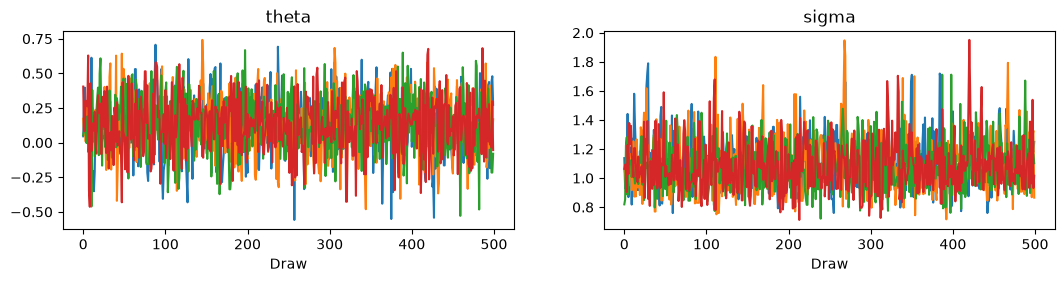

In [98]:
az.plot_trace(idata, var_names=["theta", "sigma"])


In [99]:
print(
    az.summary(
        idata,
        var_names=["theta", "sigma"]
    )
)

        mean     sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean mcse_sd
theta  0.128  0.207    -0.21     0.45     2032     1422  1.00    0.0046  0.0044
sigma   1.09  0.175     0.85      1.4     1861     1242  1.00    0.0042  0.0049


In [100]:
# Ex 4.1
import pymc as pm
import numpy as np

# --- Data and Hyperparameters ---
# The data for the exercise
X_data = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0])
Y_data = np.array([1.06, 2.07, 2.97, 4.01, 5.13, 5.92, 6.91, 0.00, 9.15, 9.90])

# Prior hyperparameters
beta_mean = 0.0
beta_std = 1.0
sigma_alpha = 0.1
sigma_beta = 1.0

# --- Model Definition ---
with pm.Model() as linear_model:
    # Priors for the intercept (beta0) and slope (beta1)
    beta0 = pm.Normal('beta0', mu=beta_mean, sigma=beta_std)
    beta1 = pm.Normal('beta1', mu=beta_mean, sigma=beta_std)
    
    # Prior for the noise standard deviation
    sigma = pm.Gamma('sigma', alpha=sigma_alpha, beta=sigma_beta)
    
    # Expected value of Y
    mu = beta0 + beta1 * X_data
    
    # Likelihood of the data
    Y_obs = pm.Normal('Y_obs', mu=mu, sigma=sigma, observed=Y_data)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta0, beta1, sigma]
Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 0 seconds.


       mean     sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean mcse_sd
beta0  0.19   0.83     -1.2      1.5     1044     1109  1.01     0.026   0.019
beta1   0.8  0.166     0.53      1.1      974     1131  1.01    0.0053  0.0038
sigma  2.34    0.5      1.7      3.2     1159     1240  1.01     0.015   0.016


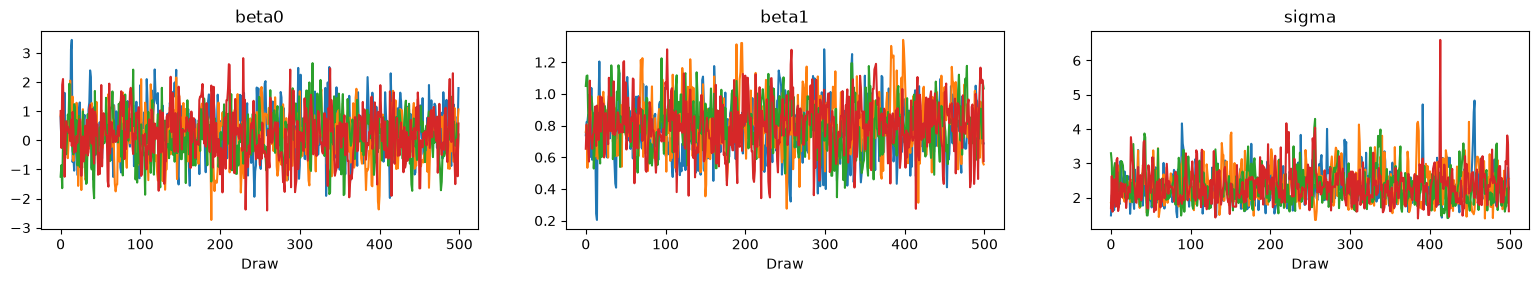

In [101]:
with linear_model:
    # Sample using NUTS (No-U-Turn Sampler)
    idata = pm.sample(draws=500, tune=500,
    random_seed=42,
    progressbar=False)

summary = (
    az.summary(
        idata,
        var_names=["beta0", "beta1", "sigma"],
    )
)
print(summary)
az.plot_trace(idata, var_names=["beta0", "beta1", "sigma"])

The chains appear well mixed and the trace plots have a fuzzy-caterpillar appearance. All R_hat values are 1.00 and the effective sample sizes are sufficiently large so there are no apparent convergence problems.

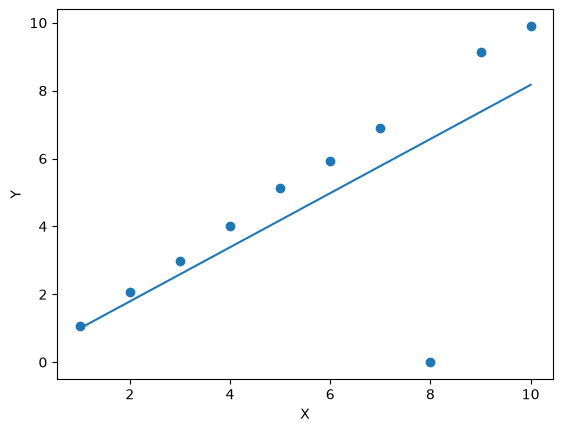

In [102]:
beta0_mean = summary.loc["beta0", "mean"]
beta1_mean = summary.loc["beta1", "mean"]

y_values = beta0_mean + beta1_mean * X_data
plt.scatter(X_data, Y_data)
plt.plot(X_data, y_values)

plt.xlabel("X")
plt.ylabel("Y")
plt.show()

x input and y output lie closetly together but the 8.0 and 0.00 thats why we see a outlier at x=8

In [103]:
# Ex 4.2
import pymc as pm
import numpy as np

# --- Data and Hyperparameters ---
# The data for the exercise
X_data = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0])
Y_data = np.array([1.06, 2.07, 2.97, 4.01, 5.13, 5.92, 6.91, 0.00, 9.15, 9.90])

# Prior hyperparameters
beta_mean = 0.0
beta_std = 1.0
sigma_alpha = 0.1
sigma_beta = 1.0

# --- Model Definition ---
with pm.Model() as linear_model:
    # Priors for the intercept (beta0) and slope (beta1)
    beta0 = pm.Normal('beta0', mu=beta_mean, sigma=beta_std)
    beta1 = pm.Normal('beta1', mu=beta_mean, sigma=beta_std)
    
    # Prior for the noise standard deviation
    sigma = pm.Gamma('sigma', alpha=sigma_alpha, beta=sigma_beta)
    
    # Expected value of Y
    mu = beta0 + beta1 * X_data

    nu=3
    
    # Likelihood of the data
    Y_obs = pm.StudentT('Y_obs', nu=nu, mu=mu, sigma=sigma, observed=Y_data)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta0, beta1, sigma]
Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 0 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


        mean     sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean mcse_sd
beta0  0.068   0.11   -0.099     0.23      620      691  1.02    0.0047  0.0077
beta1  0.987  0.019     0.96        1      642      607  1.02   0.00079  0.0014
sigma  0.136  0.068    0.063     0.26      499      547  1.01     0.003  0.0047


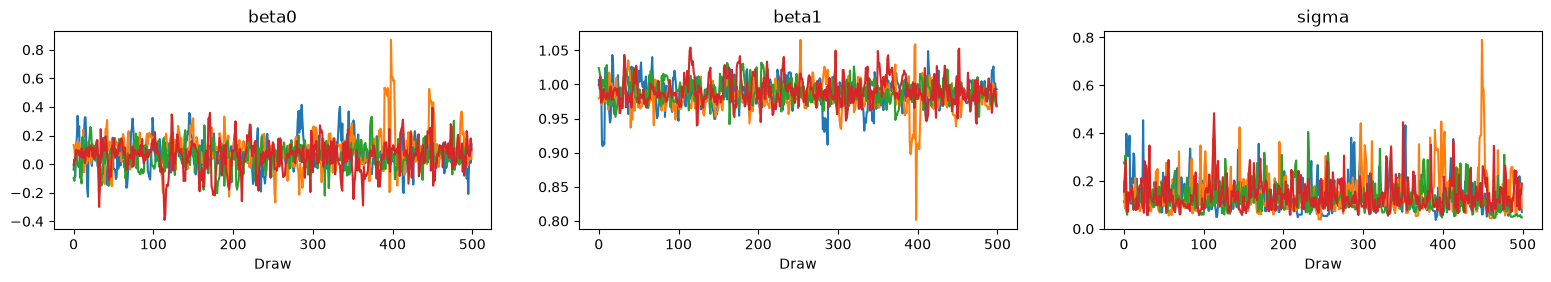

In [104]:
with linear_model:
    # Sample using NUTS (No-U-Turn Sampler)
    idata = pm.sample(draws=500, tune=500,
    random_seed=42,
    progressbar=False)

summary = (
    az.summary(
        idata,
        var_names=["beta0", "beta1", "sigma"],
    )
)
print(summary)
az.plot_trace(idata, var_names=["beta0", "beta1", "sigma"])

R_hats in beta0 and beta 1 is 1.02 >= 1.01 so i cant say this is fully converged.

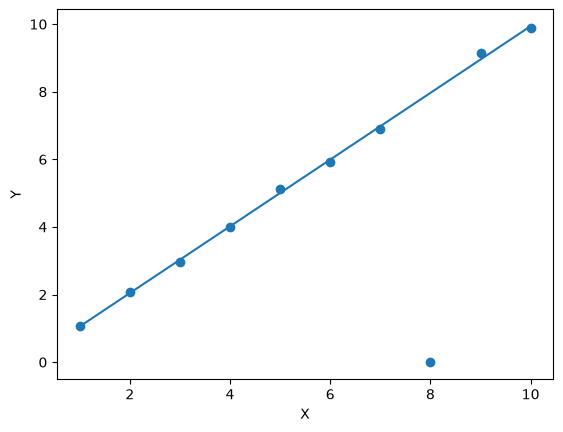

In [105]:
beta0_mean = summary.loc["beta0", "mean"]
beta1_mean = summary.loc["beta1", "mean"]

y_values = beta0_mean + beta1_mean * X_data
plt.scatter(X_data, Y_data)
plt.plot(X_data, y_values)

plt.xlabel("X")
plt.ylabel("Y")
plt.show()

Now with Student T it ignores the outlier at x=8.0

In [106]:
# Ex 5.1
import pymc as pm
import numpy as np

data = pd.read_csv("radon.txt", sep="\t")
#print(data.head())

X_data = data['floor'].values
#print(X_data)

Y_data = data['log_radon'].values
#print(Y_data)

print(data["log_radon"].describe())
print(data["floor"].value_counts())

# --- Model Definition ---
with pm.Model() as linear_model:
    # Priors for the intercept (beta0) and slope (beta1)
    beta0 = pm.Normal('beta0', mu=0, sigma=2)
    beta1 = pm.Normal('beta1', mu=0, sigma=1)
    
    # Prior for the noise standard deviation
    sigma = pm.HalfNormal("sigma", sigma=1)
    
    # Expected value of Y
    mu = beta0 + beta1 * X_data
    
    # Likelihood of the data
    five_one_Y_obs = pm.Normal('Y_obs', mu=mu, sigma=sigma, observed=Y_data)


count    919.000000
mean       1.224623
std        0.853327
min       -2.302585
25%        0.641854
50%        1.280934
75%        1.791759
max        3.875359
Name: log_radon, dtype: float64
floor
0    766
1    153
Name: count, dtype: int64


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta0, beta1, sigma]
/Users/riku.personal/miniconda3/envs/stats4ds/lib/python3.14/site-packages/pymc/sampling/mcmc.py:1178: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 0 seconds.


         mean      sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean  mcse_sd
beta0   1.325    0.03      1.3      1.4     1892     1661  1.00   0.00069   0.0006
beta1  -0.609   0.074    -0.73    -0.49     1818     1587  1.00    0.0017   0.0014
sigma  0.8235  0.0191     0.79     0.86     2920     1660  1.00   0.00035  0.00044


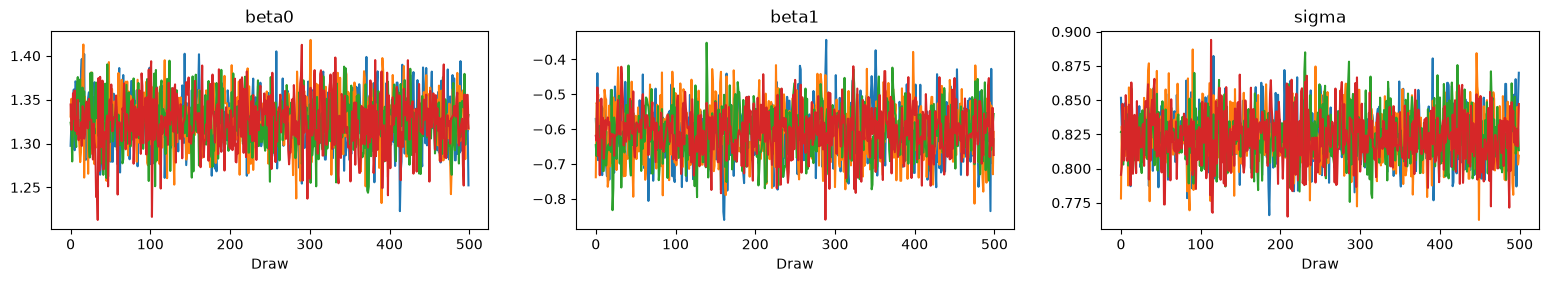

In [107]:
with linear_model:
    # Sample using NUTS (No-U-Turn Sampler)
    five_one_idata = pm.sample(draws=500, tune=500,
    random_seed=42,
    progressbar=False,
    idata_kwargs={"log_likelihood": True})

summary = (
    az.summary(
        five_one_idata,
        var_names=["beta0", "beta1", "sigma"],
    )
)
print(summary)
az.plot_trace(five_one_idata, var_names=["beta0", "beta1", "sigma"])

In [108]:
beta0_mean = summary.loc["beta0", "mean"]
beta1_mean = summary.loc["beta1", "mean"]

y_values = beta0_mean + beta1_mean * X_data

abs_pred_error = abs(Y_data - y_values)
#print(abs_pred_error)

data["abs_pred_error"] = abs_pred_error
#print(data.head())

counties = data.groupby("county")["abs_pred_error"].mean().sort_values(ascending=False)
print(counties)

county
36    1.578155
10    1.474317
17    1.375416
81    1.310053
79    1.190530
        ...   
29    0.268798
23    0.180829
85    0.138278
60    0.055613
42    0.036177
Name: abs_pred_error, Length: 85, dtype: float64


In [109]:
# Ex 5.2
import pymc as pm
import pandas as pd

data = pd.read_csv("radon.txt", sep="\t")

X_data = data['floor'].values

Y_data = data['log_radon'].values

county_idx, county_labels = pd.factorize(data["county"])
n_counties = len(county_labels)

# --- Model Definition ---
with pm.Model() as linear_model:
    mu_beta = pm.Normal('mu_beta', mu=0, sigma=2)
    sigma_beta = pm.HalfNormal("sigma_beta", sigma=1)

    # Priors for the intercept (beta0) and slope (beta1)
    beta0 = pm.Normal('beta0', mu=mu_beta, sigma=sigma_beta, shape=n_counties)
    beta1 = pm.Normal('beta1', mu=0, sigma=1)
    
    # Prior for the noise standard deviation
    sigma = pm.HalfNormal("sigma", sigma=1)
    
    # Expected value of Y
    mu = beta0[county_idx] + beta1 * X_data
    
    # Likelihoods of the data
    five_two_Y_obs = pm.Normal('Y_obs', mu=mu, sigma=sigma, observed=Y_data)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_beta, sigma_beta, beta0, beta1, sigma]
/Users/riku.personal/miniconda3/envs/stats4ds/lib/python3.14/site-packages/pymc/sampling/mcmc.py:1178: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 0 seconds.


             mean      sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean  mcse_sd
beta0[0]     1.18    0.24     0.79      1.6     2162     1479  1.00    0.0052   0.0054
beta0[1]    0.928   0.099     0.77      1.1     2456     1538  1.00     0.002   0.0021
beta0[2]     1.48    0.27      1.1      1.9     2004     1424  1.00    0.0059   0.0069
beta0[3]    1.492   0.213      1.1      1.8     2515     1478  1.00    0.0042   0.0043
beta0[4]     1.45    0.25        1      1.9     1666     1103  1.00    0.0062   0.0063
beta0[5]    1.479    0.26      1.1      1.9     2858     1495  1.00    0.0049   0.0059
beta0[6]    1.859    0.18      1.6      2.1     1974     1463  1.00    0.0041   0.0038
beta0[7]     1.68    0.25      1.3      2.1     2128     1517  1.00    0.0055   0.0062
beta0[8]    1.163     0.2     0.85      1.5     2297     1064  1.00    0.0041    0.005
beta0[9]     1.51   0.221      1.2      1.9     1943     1368  1.00     0.005   0.0048
beta0[10]    1.43    0.24      1.1      1.8

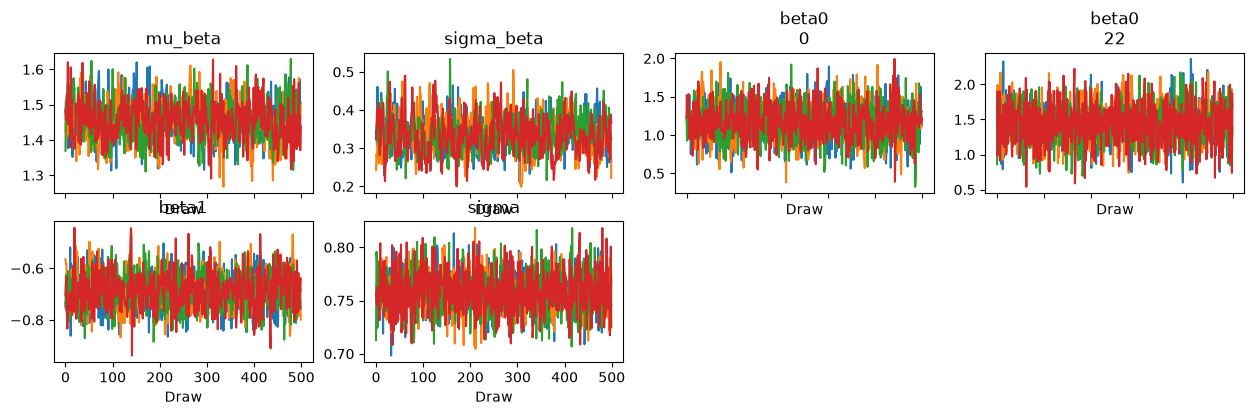

In [110]:
with linear_model:
    # Sample using NUTS (No-U-Turn Sampler)
    five_two_idata = pm.sample(draws=500, tune=500,
    random_seed=42,
    progressbar=False,
    idata_kwargs={"log_likelihood": True})

summary = (
    az.summary(
        five_two_idata,
        var_names=["beta0", "beta1", "sigma"],
    )
)
print(summary)
az.plot_trace(five_two_idata, var_names=["mu_beta", "sigma_beta", "beta0", "beta1", "sigma"], coords={"beta0_dim_0": [0, 22]}
)

In [111]:
beta0_means = summary.loc[summary.index.str.startswith("beta0["),"mean"].to_numpy()

countymean = beta0_means[county_idx]
# beta0_mean = summary.loc[countymean, "mean"]
beta1_mean = summary.loc["beta1", "mean"]

y_values = countymean + beta1_mean * X_data

abs_pred_error = abs(Y_data - y_values)
#print(abs_pred_error)

data["abs_pred_error"] = abs_pred_error
#print(data.head())

counties = data.groupby("county")["abs_pred_error"].mean().sort_values(ascending=False)
print(counties)

county
10    1.426143
17    1.376271
36    1.070398
79    1.052308
56    0.984691
        ...   
20    0.223994
23    0.219175
85    0.192979
60    0.126338
42    0.079525
Name: abs_pred_error, Length: 85, dtype: float64


The only one in the top 5 in the 5.1 ex's county is 10 which is 0.05 lower aswell. also only 2 of the counties have over 1.1 abs_pred_error here and 5.1 had many more.

In [114]:
# Ex 5.3
# print(five_one_Y_obs)
# print(five_one_idata)
# print(five_two_Y_obs)
# print(five_two_idata)

print(five_one_idata.groups)
print(five_two_idata.groups)

comp_all = az.compare({"Pooled": five_one_idata,"By county": five_two_idata})
print(comp_all.round(2))

print(comp_all.loc["By county", "elpd"])
print(comp_all.loc["Pooled", "elpd"])


('/', '/posterior', '/sample_stats', '/observed_data', '/log_likelihood')
('/', '/posterior', '/sample_stats', '/observed_data', '/log_likelihood')
           rank  elpd_diff   dse  p_worse diag_diff diag_elpd     p    elpd  \
By county     0        0.0   0.0      NaN                      49.4 -1070.0   
Pooled        1      -50.0  11.0      1.0                       3.8 -1130.0   

             se  weight  
By county  28.0    0.93  
Pooled     26.0    0.07  
-1070.0
-1130.0
